# Constraints

In [31]:
import jax.numpy as jnp

from specifications.objects.material import Material
from specifications.functions.edlen_air import edlen_prediction_batch
from specifications.functions.thermal_optics_solid import thermal_prediction_batch
from pathlib import Path
from specifications.types.optics import SpectralBand, Transmittance

In [32]:
SEED = 2026
EXPERIMENTS_DIR = "./experiments"
ORIGINAL_MATERIAL_DATA_DIR = "./original_material_data"
MAX_LAYERS = 10
TEMPERATURES = jnp.array([288, 293, 298, 303, 308])  # 15°C to 35°C in Kelvin, step 5°C
WAVELENGTHS = jnp.linspace(300e-9, 1100e-9, 800)  # 300 nm to 1100 nm, step 1 nm
COST_THRESHOLD = 0.01
MAX_GENERATIONS = 500
POPULATION_SIZE = 200
MUTATION_RATE = 0.1
CROSSOVER_RATE = 0.8
CROSSOVER_POINTS = 3
TOURNAMENT_SIZE = 3
ELITISM_FRACTION = 0.1
INCIDENCE_ANGLES = jnp.array([0.0])  # Normal incidence only for simplicity
TARGET_CLASS = Transmittance
SUPER_GAUSSIAN_CENTER = 575e-9  # 575 nm
SUPER_GAUSSIAN_WIDTH = 175e-9  # 175 nm
SUPER_GAUSSIAN_ORDER = 100
SUPER_GAUSSIAN_AMPLITUDE = 1
SUPER_GAUSSIAN_BASELINE = 0
THICKNESS_OPTIONS = jnp.arange(10e-9, 101e-9, 5e-9) # 10 nm to 100 nm, step 5 nm

In [33]:
air = Material(
    name="Air",
    symbol="Air",
    cte=0,
    files=(
        Path(f"{ORIGINAL_MATERIAL_DATA_DIR}/Air_288K.csv"),
    )
).from_prediction_batch(
    target_temperatures=jnp.array(TEMPERATURES),
    batch_prediction_function=edlen_prediction_batch
)
    
sio2 = Material(
    name="Dióxido de Silício",
    symbol="SiO2",
    cte=0.5e-6,
    files=(
        Path(f"{ORIGINAL_MATERIAL_DATA_DIR}/SiO2_298K.csv"),
    )
).from_prediction_batch(
    target_temperatures=jnp.array(TEMPERATURES),
    batch_prediction_function=thermal_prediction_batch
)

tio2 = Material(
    name="Dióxido de Titanio",
    symbol="TiO2",
    cte=0.5e-6,
    files=(
        Path(f"{ORIGINAL_MATERIAL_DATA_DIR}/TiO2_298K.csv"),
    )
).from_prediction_batch(
    target_temperatures=jnp.array(TEMPERATURES),
    batch_prediction_function=thermal_prediction_batch
)

vo2 = Material(
    name="Dióxido de Vanádio",
    symbol="VO2",
    cte=0.5e-6,
    files=(
        Path(f"{ORIGINAL_MATERIAL_DATA_DIR}/VO2_293K.csv"),
        Path(f"{ORIGINAL_MATERIAL_DATA_DIR}/VO2_303K.csv"),
    )
).from_prediction_batch(
    target_temperatures=jnp.array(TEMPERATURES),
    batch_prediction_function=thermal_prediction_batch
)

zro2 = Material(
    name="Dióxido de Zircônio",
    symbol="ZrO2",
    cte=0.5e-6,
    files=(
        Path(f"{ORIGINAL_MATERIAL_DATA_DIR}/ZrO2_298K.csv"),
        )
).from_prediction_batch(
    target_temperatures=jnp.array(TEMPERATURES),
    batch_prediction_function=thermal_prediction_batch
)

MATERIALS = [air, sio2, tio2, vo2, zro2]

In [34]:
uv_spectral_band = SpectralBand(
    start=300e-9,
    end=399e-9,
    weight=0.2
)

visible_spectral_band = SpectralBand(
    start=400e-9,
    end=749e-9,
    weight=0.5
)

nir_spectral_band = SpectralBand(
    start=750e-9,
    end=1100e-9,
    weight=0.3
)

SPECTRAL_BANDS = [uv_spectral_band, visible_spectral_band, nir_spectral_band]

In [35]:
from template.objects.template import Template, Layer, Substrate, IncidenceMedium, FreeBlock

TEMPLATE = Template(
    layer_mapping=(
        IncidenceMedium(material_symbol="Air"),
        Layer(material_symbol="ZrO2"),
        Layer(material_symbol="VO2"),
        Layer(material_symbol="ZrO2"),
        Substrate(material_symbol="SiO2")
    ),
    max_layers=MAX_LAYERS
)

In [36]:
from experiment.objects.experiment_config import ExperimentConfig

config = ExperimentConfig(
    seed=2026,
    materials=MATERIALS,
    thickness_options=THICKNESS_OPTIONS,
    template=TEMPLATE,
    temperatures=TEMPERATURES,
    wavelengths=WAVELENGTHS,
    angles=INCIDENCE_ANGLES,
    target_class=Transmittance,
    target_center=SUPER_GAUSSIAN_CENTER,
    target_width=SUPER_GAUSSIAN_WIDTH,
    target_order=SUPER_GAUSSIAN_ORDER,
    target_amplitude=SUPER_GAUSSIAN_AMPLITUDE,
    target_baseline=SUPER_GAUSSIAN_BASELINE,
    bands=SPECTRAL_BANDS,
    population_size=POPULATION_SIZE,
    max_generations=MAX_GENERATIONS,
    cost_threshold=COST_THRESHOLD,
    elite_fraction=ELITISM_FRACTION,
    tournament_size=TOURNAMENT_SIZE,
    mutation_rate=MUTATION_RATE,
    crossover_rate=CROSSOVER_RATE,
    crossover_points=CROSSOVER_POINTS,
)

print(f"Experiment hash: {config.hash}")        # e.g., "3f8a2b1c9d4e"
print(f"Experiment path: {config.get_path}")    # experiments/3f8a2b1c9d4e

Experiment hash: 7ec56dc9df82
Experiment path: experiments/7ec56dc9df82


# Validations

In [37]:
from pathlib import Path
import csv

def convert_directory_m_to_um(input_dir, output_dir, new_header='wavelength_um,n,k'):
    """
    Converte todos os ficheiros CSV do diretório de entrada, assumindo que
    a primeira coluna é o comprimento de onda em metros.
    Os ficheiros convertidos (com comprimento de onda em micrómetros) são
    guardados no diretório de saída com o mesmo nome.
    O comprimento de onda é escrito em micrómetros (1 m = 1e6 µm),
    em formato decimal (ex.: 0.400000), sem notação científica.
    """
    input_path = Path(input_dir)
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    csv_files = list(input_path.glob('*.csv'))
    if not csv_files:
        print(f"Nenhum ficheiro CSV encontrado em {input_path}")
        return

    for file_in in csv_files:
        file_out = output_path / file_in.name  # mesmo nome no diretório de saída

        with file_in.open('r', newline='', encoding='utf-8') as f:
            reader = csv.reader(f)
            header = next(reader)               # ignorar o cabeçalho original
            rows = []
            for row in reader:
                if not row:                     # saltar linhas vazias
                    continue
                wl_m = float(row[0])
                wl_um = wl_m * 1e6              # metros → micrómetros
                row[0] = f"{wl_um:.6f}"         # formato decimal, 6 casas decimais
                rows.append(row)

        with file_out.open('w', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            writer.writerow(new_header.split(','))
            writer.writerows(rows)

        print(f"Convertido: {file_in.name} → {file_out}")

    print(f"Conversão completa. {len(csv_files)} ficheiro(s) processado(s).")


def convert_directory_m_to_nm_split_nk(input_dir, output_dir):
    """
    Converte todos os ficheiros CSV do diretório de entrada, assumindo que
    a primeira coluna é o comprimento de onda em METROS.
    Para cada ficheiro de entrada, gera dois ficheiros no diretório de saída:
        <nome>_n.csv  -> colunas: wavelength_nm, n
        <nome>_k.csv  -> colunas: wavelength_nm, k
    O comprimento de onda é escrito em nanómetros (1 m = 1e9 nm),
    em formato decimal (ex.: 400.000000), sem notação científica.
    """
    input_path = Path(input_dir)
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    csv_files = list(input_path.glob('*.csv'))
    if not csv_files:
        print(f"Nenhum ficheiro CSV encontrado em {input_path}")
        return

    for file_in in csv_files:
        stem = file_in.stem

        with file_in.open('r', newline='', encoding='utf-8') as f:
            reader = csv.reader(f)
            header = next(reader)
            n_rows = []
            k_rows = []
            for row in reader:
                if not row:
                    continue
                wl_m = float(row[0])
                wl_nm = wl_m * 1e9
                wl_str = f"{wl_nm:.6f}"
                n_val = row[1]
                k_val = row[2]
                n_rows.append([wl_str, n_val])
                k_rows.append([wl_str, k_val])

        file_n = output_path / f"{stem}_n.csv"
        with file_n.open('w', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            writer.writerow(['wavelength_nm', 'n'])
            writer.writerows(n_rows)

        file_k = output_path / f"{stem}_k.csv"
        with file_k.open('w', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            writer.writerow(['wavelength_nm', 'k'])
            writer.writerows(k_rows)

        print(f"Convertido: {file_in.name} → {file_n.name} e {file_k.name}")

    print(f"Conversão completa. {len(csv_files)} ficheiro(s) processado(s).")

# Exemplo de uso:
convert_directory_m_to_um('database/csv', 'dados/micrometros')

from pathlib import Path
import csv

def convert_directory_m_to_nm_split_nk(input_dir, output_dir):
    """
    Converte todos os ficheiros CSV do diretório de entrada, assumindo que
    a primeira coluna é o comprimento de onda em METROS.
    Para cada ficheiro de entrada, gera dois ficheiros no diretório de saída:
        <nome>_n.csv  -> colunas: wavelength_nm, n
        <nome>_k.csv  -> colunas: wavelength_nm, k
    O comprimento de onda é escrito em nanómetros (1 m = 1e9 nm),
    em formato decimal (ex.: 400.000000), sem notação científica.
    """
    input_path = Path(input_dir)
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    csv_files = list(input_path.glob('*.csv'))
    if not csv_files:
        print(f"Nenhum ficheiro CSV encontrado em {input_path}")
        return

    for file_in in csv_files:
        stem = file_in.stem  # nome sem extensão

        with file_in.open('r', newline='', encoding='utf-8') as f:
            reader = csv.reader(f)
            header = next(reader)  # ignorar cabeçalho original
            n_rows = []
            k_rows = []
            for row in reader:
                if not row:      # saltar linhas vazias
                    continue
                # Conversão: metros → nanómetros (1 m = 1e9 nm)
                wl_m = float(row[0])
                wl_nm = wl_m * 1e9
                # Formatação: decimal com 6 casas (ex.: 400.000000)
                wl_str = f"{wl_nm:.6f}"
                # Colunas originais: wl, n, k
                n_val = row[1]
                k_val = row[2]
                n_rows.append([wl_str, n_val])
                k_rows.append([wl_str, k_val])

        # Gravar ficheiro com n
        file_n = output_path / f"{stem}_n.csv"
        with file_n.open('w', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            writer.writerow(['wavelength_nm', 'n'])
            writer.writerows(n_rows)

        # Gravar ficheiro com k
        file_k = output_path / f"{stem}_k.csv"
        with file_k.open('w', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            writer.writerow(['wavelength_nm', 'k'])
            writer.writerows(k_rows)

        print(f"Convertido: {file_in.name} → {file_n.name} e {file_k.name}")

    print(f"Conversão completa. {len(csv_files)} ficheiro(s) processado(s).")

# Exemplo de uso:
convert_directory_m_to_nm_split_nk('database/csv', 'dados/nanometros')

Convertido: Air_288K.csv → dados/micrometros/Air_288K.csv
Convertido: Air_293K.csv → dados/micrometros/Air_293K.csv
Convertido: Air_298K.csv → dados/micrometros/Air_298K.csv
Convertido: Air_303K.csv → dados/micrometros/Air_303K.csv
Convertido: Air_308K.csv → dados/micrometros/Air_308K.csv
Convertido: SiO2_288K.csv → dados/micrometros/SiO2_288K.csv
Convertido: SiO2_293K.csv → dados/micrometros/SiO2_293K.csv
Convertido: SiO2_298K.csv → dados/micrometros/SiO2_298K.csv
Convertido: SiO2_303K.csv → dados/micrometros/SiO2_303K.csv
Convertido: SiO2_308K.csv → dados/micrometros/SiO2_308K.csv
Convertido: SiO2_573K.csv → dados/micrometros/SiO2_573K.csv
Convertido: TiO2_288K.csv → dados/micrometros/TiO2_288K.csv
Convertido: TiO2_293K.csv → dados/micrometros/TiO2_293K.csv
Convertido: TiO2_298K.csv → dados/micrometros/TiO2_298K.csv
Convertido: TiO2_303K.csv → dados/micrometros/TiO2_303K.csv
Convertido: TiO2_308K.csv → dados/micrometros/TiO2_308K.csv
Convertido: VO2_288K.csv → dados/micrometros/VO2_2

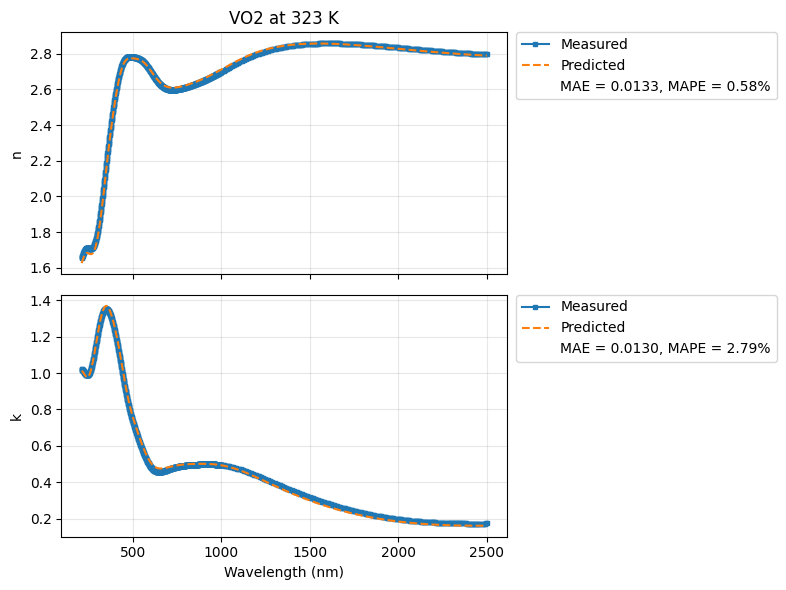

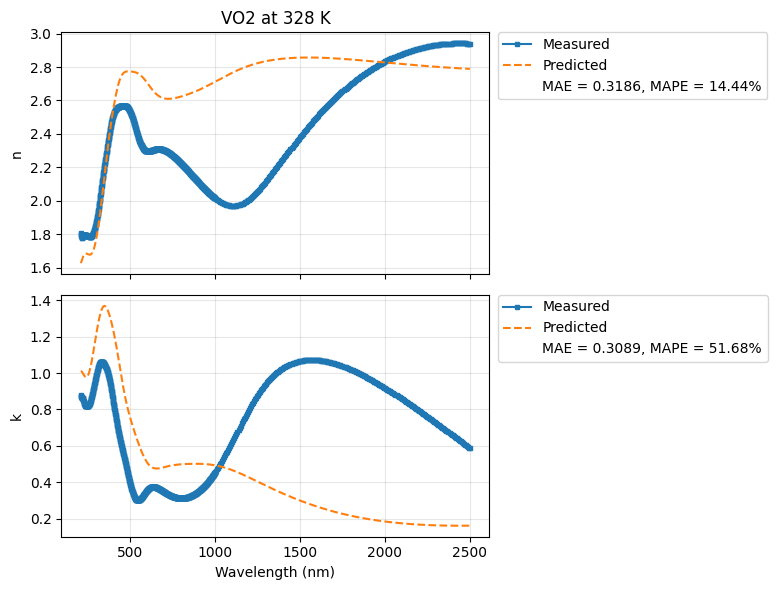

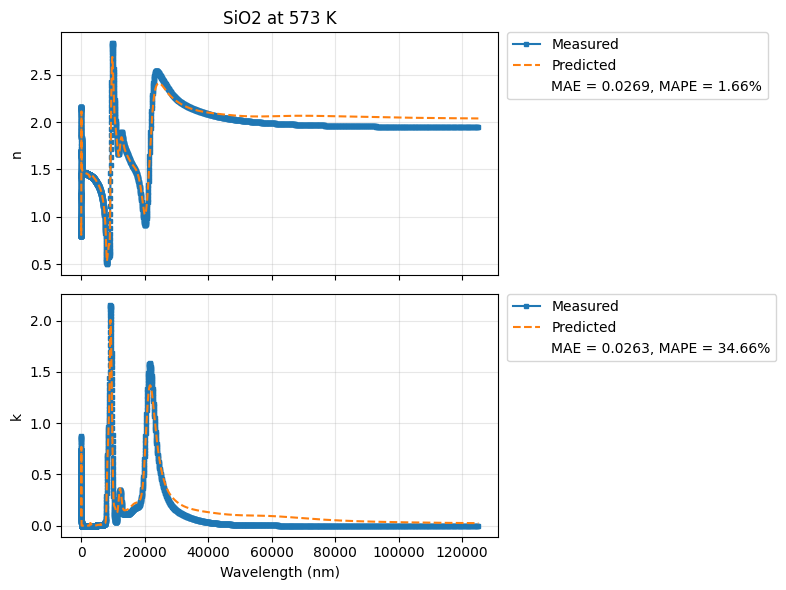

In [38]:
from pathlib import Path
from typing import Union
import matplotlib.pyplot as plt
import jax.numpy as jnp
from specifications.objects.material import Material
from specifications.functions.load_nk_data_from_csv import load_nk_data_from_csv


def compare_material_prediction(
    material: Material,
    temperature: float,
    original_data_dir: Union[str, Path],
    epsilon: float = 1e-6,
) -> None:
    """
    Compare the thermally‑predicted n,k with the original measured data.

    The original CSV file is expected to be named ``<symbol>_<temperature>K.csv``
    and contain wavelengths in **micrometres**. The predicted data is obtained
    from the material via ``get_data_by_temperature``.

    Both curves are plotted on the material's wavelength grid, and the
    following metrics are displayed inside the legend of each panel:
      - MAE  (mean absolute error)
      - MAPE (mean absolute percentage error, for n always; for k only
              at wavelengths where the measured value exceeds 1% of its
              maximum, to avoid meaningless percentages on noise).

    Args:
        material:          Material object with temperature‑dependent data.
        temperature:       Temperature in Kelvin.
        original_data_dir: Directory containing the original CSV files.
        epsilon:           Threshold for MAPE computation of n (avoids
                           division by very small values).
    """
    original_dir = Path(original_data_dir)

    # ------------------------------------------------------------------
    # 1.  Load original measured data
    # ------------------------------------------------------------------
    temp_str = f"{int(temperature)}K" if temperature == int(temperature) else f"{temperature}K"
    file_path = original_dir / f"{material.symbol}_{temp_str}.csv"
    if not file_path.exists():
        raise FileNotFoundError(f"Original data file not found: {file_path}")

    wl_um_orig, n_orig, k_orig = load_nk_data_from_csv(file_path)
    wl_m_orig = jnp.asarray(wl_um_orig, dtype=jnp.float32) * 1e-6

    # ------------------------------------------------------------------
    # 2.  Get predicted data from the material
    # ------------------------------------------------------------------
    wl_m_pred, n_pred, k_pred = material.get_data_by_temperature(temperature)

    # ------------------------------------------------------------------
    # 3.  Interpolate original data onto the prediction grid
    # ------------------------------------------------------------------
    n_orig_interp = jnp.interp(wl_m_pred, wl_m_orig, n_orig)
    k_orig_interp = jnp.interp(wl_m_pred, wl_m_orig, k_orig)

    # ------------------------------------------------------------------
    # 4.  Metrics
    # ------------------------------------------------------------------
    mae_n = float(jnp.mean(jnp.abs(n_pred - n_orig_interp)))
    mae_k = float(jnp.mean(jnp.abs(k_pred - k_orig_interp)))

    # MAPE for n – standard, using the small epsilon to skip near‑zero n
    mask_n = jnp.abs(n_orig_interp) > epsilon
    mape_n = float(
        jnp.mean(jnp.abs((n_pred[mask_n] - n_orig_interp[mask_n]) / n_orig_interp[mask_n])) * 100.0
    ) if jnp.any(mask_n) else 0.0

    # MAPE for k – only for wavelengths where the measured k is significant
    # (at least 1% of the maximum measured k). This avoids exploding MAPE
    # for materials that are essentially non‑absorptive.
    max_k_orig = float(jnp.max(k_orig_interp))
    dynamic_threshold = max(epsilon, 0.01 * max_k_orig)
    mask_k = k_orig_interp > dynamic_threshold
    if jnp.any(mask_k):
        mape_k = float(
            jnp.mean(jnp.abs((k_pred[mask_k] - k_orig_interp[mask_k]) / k_orig_interp[mask_k])) * 100.0
        )
        k_suffix = f"MAPE = {mape_k:.2f}%"
    else:
        # Material is essentially non‑absorptive; MAPE is not meaningful
        mape_k = 0.0
        k_suffix = "MAPE: N/A"

    # Legend labels for the error metrics
    err_label_n = f'MAE = {mae_n:.4f}, MAPE = {mape_n:.2f}%'
    err_label_k = f'MAE = {mae_k:.4f}, {k_suffix}'

    # ------------------------------------------------------------------
    # 5.  Plotting
    # ------------------------------------------------------------------
    wl_nm = wl_m_pred * 1e9   # nm

    fig, (ax_n, ax_k) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

    # --- Refractive index n ---
    ax_n.plot(wl_nm, n_orig_interp, 's-', markersize=3, label='Measured')
    ax_n.plot(wl_nm, n_pred, '--', label='Predicted')
    ax_n.add_line(plt.Line2D([], [], linestyle='none', marker='none', label=err_label_n))
    ax_n.set_ylabel('n')
    ax_n.grid(True, alpha=0.3)
    ax_n.set_title(f'{material.symbol} at {temperature} K')
    ax_n.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)

    # --- Extinction coefficient k ---
    ax_k.plot(wl_nm, k_orig_interp, 's-', markersize=3, label='Measured')
    ax_k.plot(wl_nm, k_pred, '--', label='Predicted')
    ax_k.add_line(plt.Line2D([], [], linestyle='none', marker='none', label=err_label_k))
    ax_k.set_xlabel('Wavelength (nm)')
    ax_k.set_ylabel('k')
    ax_k.grid(True, alpha=0.3)
    ax_k.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)

    plt.tight_layout()
    plt.show()

validation_vo2 = vo2.from_prediction_batch(
    target_temperatures=[323, 328],
    batch_prediction_function=thermal_prediction_batch
)

validation_sio2 = sio2.from_prediction_batch(
    target_temperatures=[573],
    batch_prediction_function=thermal_prediction_batch
)

compare_material_prediction(
    material=validation_vo2,
    temperature=323,
    original_data_dir=Path(f"{ORIGINAL_MATERIAL_DATA_DIR}"),
)

compare_material_prediction(
    material=validation_vo2,
    temperature=328,
    original_data_dir=Path(f"{ORIGINAL_MATERIAL_DATA_DIR}"),
)

compare_material_prediction(
    material=validation_sio2,
    temperature=573,
    original_data_dir=Path(f"{ORIGINAL_MATERIAL_DATA_DIR}"),
)


# Execution

In [39]:
from typing import Tuple
import json
import jax

from specifications.objects.structure import Structure
from specifications.objects.environment import Environment
from genetic_algorithm.functions.target import super_gaussian_target
from genetic_algorithm.functions.initialize_population import initialize_population
from genetic_algorithm.functions.evaluate_population import evaluate_population
from genetic_algorithm.functions.select_parents import select_parent_pairs
from genetic_algorithm.functions.crossover import crossover_structures
from genetic_algorithm.functions.mutate_population import mutate_population
from genetic_algorithm.functions.replace_population import replace_population
from genetic_algorithm.functions.convert_structures_to_population import structures_to_population
from experiment.functions.load_checkpoint import load_checkpoint
from experiment.functions.save_checkpoint import save_checkpoint
from experiment.functions.save_generation_data import save_generation_data
from genetic_algorithm.functions.state import (
    update_best5, save_best5, save_elites, save_cost_history, load_cost_history
)
from experiment.functions.generate_report import generate_experiment_report

def execute_genetic_algorithm(config: ExperimentConfig) -> Tuple[Structure, float]:
    """
    Run the complete genetic algorithm with automatic checkpointing.

    The algorithm keeps an all‑time top‑5 archive, saves the final
    elite individuals, and records the best cost per generation.
    The cost history is updated **after every generation**, so it
    can be recovered in case of interruption.

    Returns:
        best_structure: Structure with the lowest cost found during the run.
        best_cost:      Cost of that structure.
    """
    experiment_dir = config.get_path
    experiment_dir.mkdir(parents=True, exist_ok=True)

    # Save configuration for reproducibility
    with open(experiment_dir / "config.json", "w") as f:
        json.dump(config.to_dict(), f, indent=2)

    # ------------------------------------------------------------------
    # 1.  Environment, materials, target, spectral bands
    # ------------------------------------------------------------------
    env = Environment(
        temperatures=config.temperatures,
        angles=config.angles,
        wavelengths=config.wavelengths,
    )
    materials = config.materials
    thickness_options = config.thickness_options

    target = super_gaussian_target(
        wavelengths=config.wavelengths,
        target_cls=config.target_class,
        center=config.target_center,
        width=config.target_width,
        order=config.target_order,
        amplitude=config.target_amplitude,
        baseline=config.target_baseline,
    )
    bands = tuple(config.bands)

    # ------------------------------------------------------------------
    # 2.  Resume from checkpoint or start from scratch
    # ------------------------------------------------------------------
    checkpoint = load_checkpoint(experiment_dir)
    if checkpoint is not None:
        generation, best_structure, best_cost, population, key, best5 = checkpoint
        print(f"Resuming from generation {generation}, best cost = {best_cost:.6f}")
        results = evaluate_population(env, population, materials, target, bands)
        start_gen = generation + 1
        cost_history = load_cost_history(experiment_dir)   # keep previous history
    else:
        # Fresh run
        key = jax.random.PRNGKey(config.seed)
        key, population = initialize_population(
            template=config.template,
            key=key,
            materials=materials,
            thickness_options_m=thickness_options,
            population_size=config.population_size,
        )
        results = evaluate_population(env, population, materials, target, bands)

        best_result = min(results, key=lambda r: r.cost)
        best_cost = best_result.cost
        best_structure = best_result.structure
        best5 = update_best5([], results)

        start_gen = 1
        print(f"Generation 0: best cost = {best_cost:.6f}")
        save_generation_data(experiment_dir, 0, results, best_result, env, target, materials)

        # Initialize cost history and save generation 0 immediately
        cost_history = [float(best_cost)]
        save_cost_history(experiment_dir, cost_history)

    # ------------------------------------------------------------------
    # 3.  Evolution loop
    # ------------------------------------------------------------------
    for gen in range(start_gen, config.max_generations + 1):
        if best_cost <= config.cost_threshold:
            print(f"Cost threshold reached at generation {gen-1}.")
            break

        key, parent_pairs = select_parent_pairs(
            results, key,
            elite_frac=config.elite_fraction,
            tournament_size=config.tournament_size,
        )

        key, offspring_structs = crossover_structures(
            parent_pairs, key,
            n_cuts=config.crossover_points,
            crossover_rate=config.crossover_rate,
        )

        if not offspring_structs:
            continue

        offspring_pop = structures_to_population(offspring_structs)
        key, offspring_pop = mutate_population(
            offspring_pop, key,
            material_database=materials,
            thickness_options=thickness_options,
            mutation_rate=config.mutation_rate,
        )

        offspring_results = evaluate_population(
            env, offspring_pop, materials, target, bands
        )

        next_pop = replace_population(
            results, offspring_results,
            elite_frac=config.elite_fraction,
        )

        population = next_pop
        results = evaluate_population(env, population, materials, target, bands)

        current_best = min(results, key=lambda r: r.cost)
        if current_best.cost < best_cost:
            best_cost = current_best.cost
            best_structure = current_best.structure

        best5 = update_best5(best5, results)

        print(f"Generation {gen}: best cost = {best_cost:.6f}")

        # Update and save cost history after each generation
        cost_history.append(float(best_cost))
        save_cost_history(experiment_dir, cost_history)

        save_checkpoint(experiment_dir, gen, best_structure, best_cost, population, key, best5)
        save_generation_data(experiment_dir, gen, results, current_best, env, target, materials)

    # ------------------------------------------------------------------
    # 4.  Final outputs (history already saved, just finalise archives)
    # ------------------------------------------------------------------
    save_best5(experiment_dir, best5)
    save_elites(experiment_dir, results, config.elite_fraction)

    # ------------------------------------------------------------------
    # 5.  Generate final report
    # ------------------------------------------------------------------
    generate_experiment_report(experiment_dir, env, target, materials)

    return best_structure, best_cost

Resuming from generation 5, best cost = 0.360916
Generation 6: best cost = 0.360916


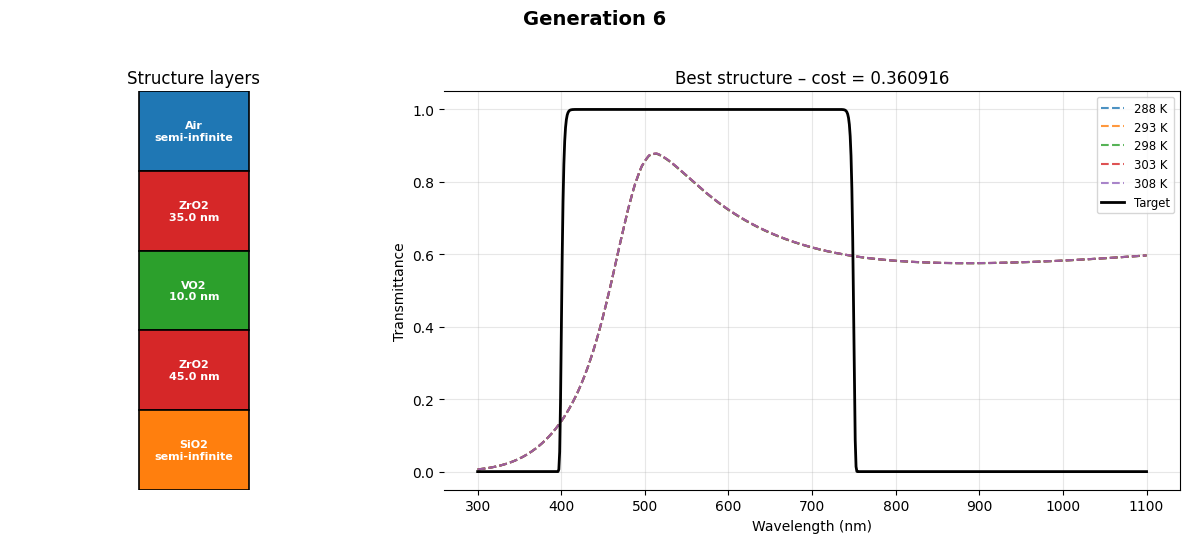

Generation 7: best cost = 0.360916


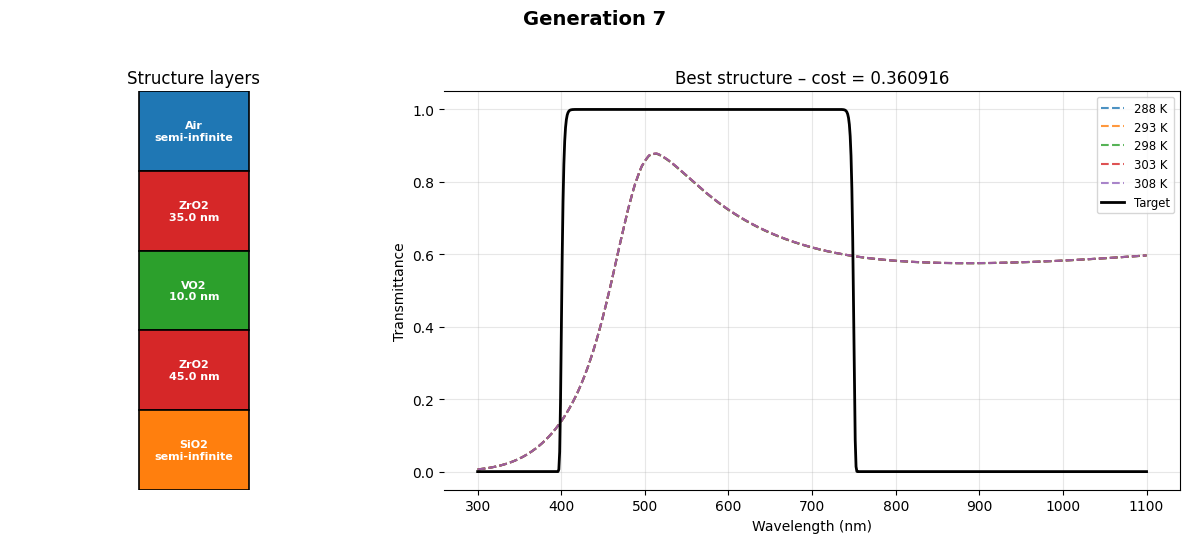

Generation 8: best cost = 0.360916


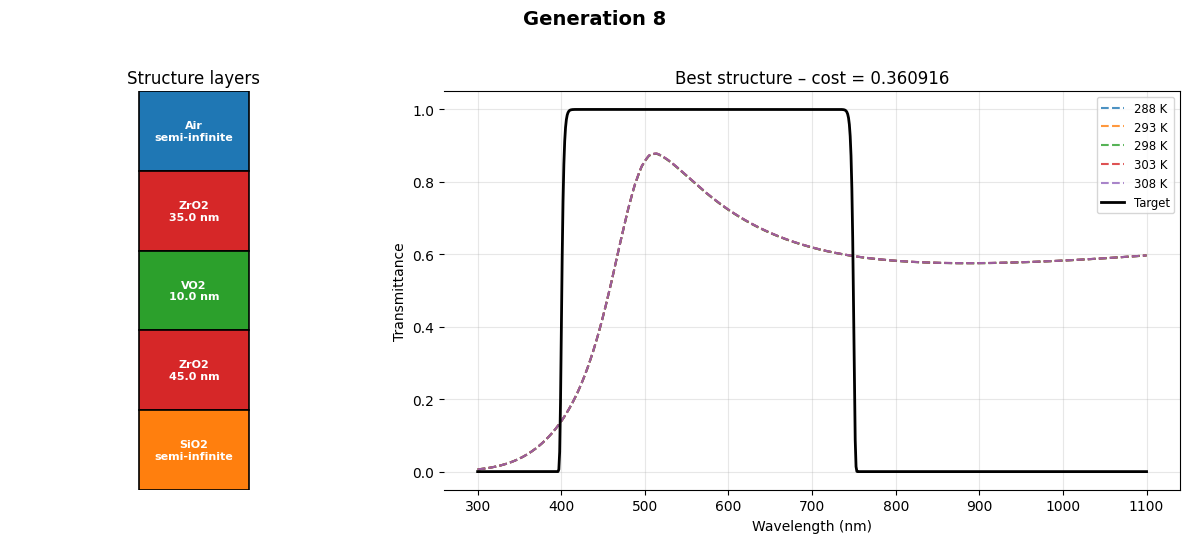

Generation 9: best cost = 0.360916


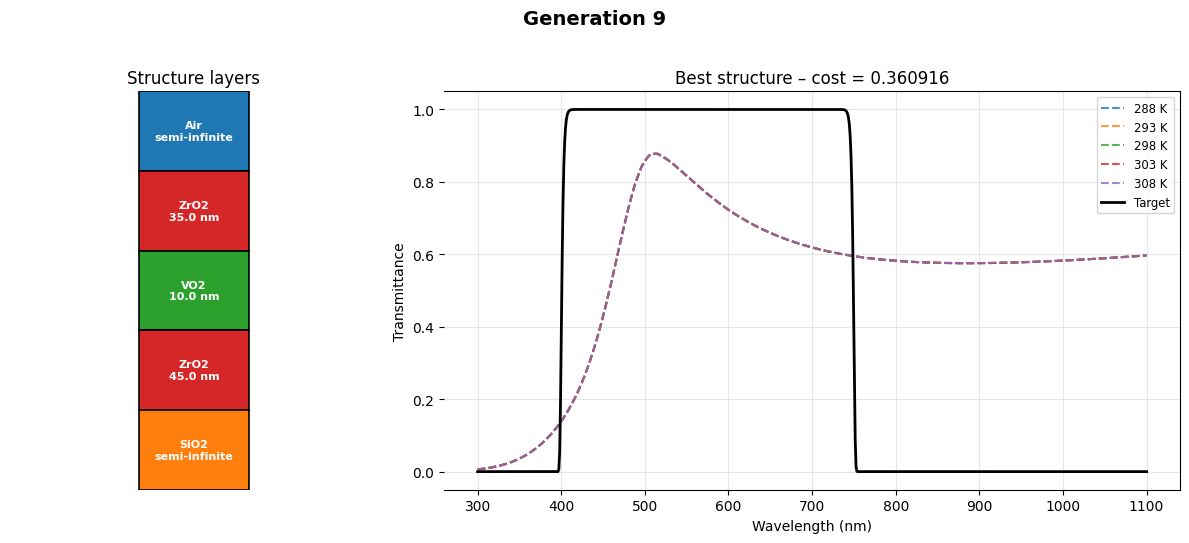

Generation 10: best cost = 0.360916


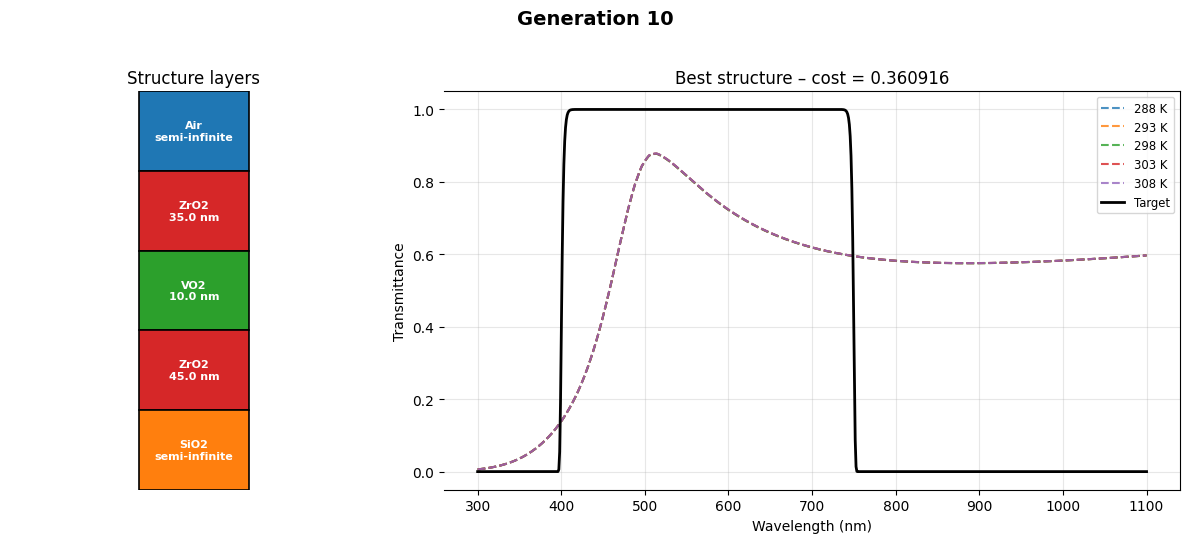

KeyboardInterrupt: 

In [40]:
execute_genetic_algorithm(config=config)